# DeepLense agent demo (Pydantic AI + DeepLenseSim)

This notebook satisfies the submission requirement to **show the implementation** and **discuss strategy**, while remaining runnable **without API keys**.

---

## Strategy discussion

### Why Pydantic AI

- **Same models everywhere**: `SimulationRequest`, `SimulationRunResult`, and `ParameterValidationReport` are Pydantic v2 models. Pydantic AI uses those schemas for **structured tool arguments and returns**, so the LLM (when used) cannot silently drift into invalid keys—the framework validates tool calls the same way we validate REST or CLI payloads.
- **Structured tool calling**: Tools are plain functions with typed parameters (`SimulationRequest`, `dict` for raw validation). That keeps the **simulation runner** (`deeplense_agent/runner.py`) decoupled from any provider-specific prompt hacks.
- **Testability**: Pydantic AI provides a **`FunctionModel`**: a local “model” implemented as a Python function that returns `ModelResponse` objects (tool calls or final text). We use that here so evaluators see a real `Agent.run()` loop—validate → human confirm → execute—**without configuring `OPENAI_API_KEY`**.

### Human-in-the-loop: SHA-256 digest gate

Interactive runs require an explicit approval step before physics execution:

1. After validation, `human_confirm_plan` (CLI) or `human_confirm_plan_tool` (agent) presents the plan.
2. On approval, we compute **`approved_digest = SHA256(spec.model_dump_json())`** and store it on `SessionState`.
3. `execute_deeplense_simulation` (when `interactive_hitl=True` and auto-approve env is off) **requires** `approved_digest == SHA256(current spec)` or it raises. That prevents “drive-by” execution if the model mutates parameters between confirm and run.

In this notebook, `AgentDeps(interactive_hitl=False)` bypasses stdin and digest enforcement so cells run headlessly; the **CLI** path demonstrates the full gate.

### Model tiers demonstrated

- **Model II (Euclid / SimAPI)**: example 1 — matches `Model_II/` scripts.
- **Model I (classic cutout)**: example 2 — matches `Model_I/` `simple_sim`-style pipeline with configurable `num_pix`.


In [1]:
%matplotlib inline

from __future__ import annotations

import asyncio
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt

# Locate repo root (folder containing both deeplense_agent/ and DeepLenseSim/)
REPO_ROOT = Path.cwd().resolve()
for p in [REPO_ROOT, *REPO_ROOT.parents]:
    if (p / "deeplense_agent").is_dir() and (p / "DeepLenseSim").is_dir():
        REPO_ROOT = p
        break
SIM_ROOT = REPO_ROOT / "DeepLenseSim"
if SIM_ROOT.is_dir():
    sys.path.insert(0, str(SIM_ROOT))

os.chdir(REPO_ROOT)
print("REPO_ROOT:", REPO_ROOT)
print("DeepLenseSim on path:", SIM_ROOT.is_dir())

REPO_ROOT: D:\Main Project\DeepLense
DeepLenseSim on path: True


## Example 1 — Scripted agent, Model II CDM (no API key)

Natural-language-style *prompt* string for logging; the **`FunctionModel`** drives the same tools a real LLM would call.

In [3]:
from deeplense_agent.models import ModelTier, SimulationRequest, SubstructureType
from deeplense_agent.notebook_demo import build_notebook_scripted_agent
from deeplense_agent.tools_runtime import AgentDeps, SessionState

OUT1 = REPO_ROOT / "deeplense_agent_outputs" / "notebook_demo_model_ii"
OUT1.mkdir(parents=True, exist_ok=True)

spec_ii = SimulationRequest(
    tier=ModelTier.MODEL_II,
    substructure=SubstructureType.CDM,
    num_images=1,
    z_lens=0.5,
    z_source=1.0,
    seed=7,
)

agent_ii = build_notebook_scripted_agent(
    spec_ii,
    summary="Model II, CDM substructure, 1 image, Euclid-style SimAPI.",
)
deps_ii = AgentDeps(interactive_hitl=False, output_dir=OUT1, session=SessionState())

PROMPT_II = (
    "Generate 1 Model II CDM lens image with z_lens=0.5 and z_source=1.0 "
    "(notebook uses FunctionModel to call tools; no OpenAI key required)."
)

result_ii = await agent_ii.run(PROMPT_II, deps=deps_ii)
# result_ii = asyncio.run(agent_ii.run(PROMPT_II, deps=deps_ii))

print("=== Final agent text output ===")
print(result_ii.output)
print("\n=== Message trace (JSON, truncated tool payloads) ===")
print(result_ii.all_messages_json()[:4000].decode("utf-8", errors="replace"), "...")

=== Final agent text output ===
Scripted run finished. See tool returns for SimulationRunResult (paths to .npy / .png).

=== Message trace (JSON, truncated tool payloads) ===
[{"parts":[{"content":"You are a scientific assistant for gravitational lensing simulations (DeepLenseSim).\n\nGoals:\n1. If the user is vague (missing tier, substructure, counts, or redshifts), ask concise clarifying questions before proposing parameters.\n2. When you have a concrete plan, build a single JSON object that matches the `SimulationRequest` schema and pass it to `validate_simulation_parameters`.\n3. If validation fails, explain gaps to the user and iterate.\n4. Before any expensive run, call `human_confirm_plan` with a short human-readable summary plus the validated `SimulationRequest` object (interactive sessions only).\n5. After approval, call `execute_deeplense_simulation` with the same `SimulationRequest` instance.\n\nTier hints from user language:\n- \"high resolution cutout\", \"150 pixels\", \"

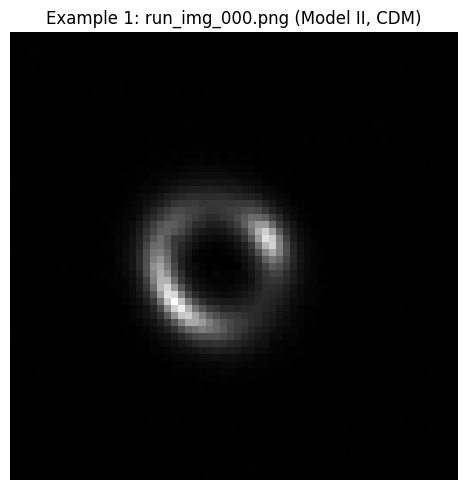

In [4]:
png_ii = OUT1 / "run_img_000.png"
assert png_ii.is_file(), f"Missing {png_ii} — run previous cell"

img = plt.imread(png_ii)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img, cmap="gray")
ax.set_title("Example 1: run_img_000.png (Model II, CDM)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Example 2 — Scripted agent, Model I no substructure

Same agent machinery; different `SimulationRequest` (classic `simple_sim`-style cutout).

In [6]:
OUT2 = REPO_ROOT / "deeplense_agent_outputs" / "notebook_demo_model_i"
OUT2.mkdir(parents=True, exist_ok=True)

spec_i = SimulationRequest(
    tier=ModelTier.MODEL_I,
    substructure=SubstructureType.NO_SUB,
    num_images=1,
    num_pix=150,
    z_lens=0.5,
    z_source=1.5,
    seed=11,
)

agent_i = build_notebook_scripted_agent(
    spec_i,
    summary="Model I, no substructure, 150x150 cutout.",
)
deps_i = AgentDeps(interactive_hitl=False, output_dir=OUT2, session=SessionState())

PROMPT_I = "One Model I no-substructure lens at z_lens=0.5, z_source=1.5, default resolution."

result_i = await agent_i.run(PROMPT_I, deps=deps_i)
# result_i = asyncio.run(agent_i.run(PROMPT_I, deps=deps_i))


print("=== Final agent text output ===")
print(result_i.output)

=== Final agent text output ===
Scripted run finished. See tool returns for SimulationRunResult (paths to .npy / .png).


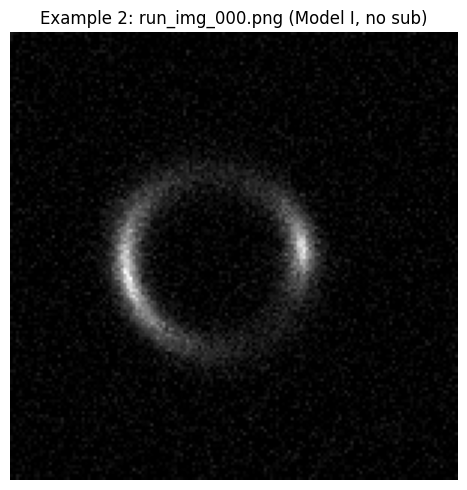

In [7]:
png_i = OUT2 / "run_img_000.png"
assert png_i.is_file(), f"Missing {png_i}"

img = plt.imread(png_i)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img, cmap="gray")
ax.set_title("Example 2: run_img_000.png (Model I, no sub)")
ax.axis("off")
plt.tight_layout()
plt.show()

## Optional — real LLM (`OPENAI_API_KEY`)

If you set `OPENAI_API_KEY`, uncomment below to run **`build_agent()`** with a live model and a natural-language prompt. This is **not** required for grading the physics path.

In [8]:
# from deeplense_agent.agent_app import build_agent
# if os.environ.get("OPENAI_API_KEY"):
#     live = build_agent()
#     deps_live = AgentDeps(interactive_hitl=False, output_dir=OUT1, session=SessionState())
#     os.environ["DEEPLENSE_AUTO_APPROVE"] = "1"
#     out = asyncio.run(
#         live.run("Generate 1 Model II CDM image z_lens=0.5 z_source=1.0", deps=deps_live)
#     )
#     print(out.output)
# else:
#     print("Skip: set OPENAI_API_KEY to run live LLM cell.")